### Loading Dataset

In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.manifold import TSNE

df = pd.read_csv('How-To-Make-ML/tSNE/ansure_male.csv')

In [2]:
df

,Branch,Component,Gender,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,...,waistdepth,waistfrontlengthsitting,waistheightomphalion,wristcircumference,wristheight,weight_kg,stature_m,BMI,BMI_class,Height_class
0,Combat Arms,Regular Army,Male,266,1467,337,222,1347,253,202,...,240,440,1054,175,853,81.5,1.776,25.838761,Overweight,Tall
1,Combat Support,Regular Army,Male,233,1395,326,220,1293,245,193,...,225,371,1054,167,815,72.6,1.702,25.062103,Overweight,Normal
2,Combat Support,Regular Army,Male,287,1430,341,230,1327,256,196,...,255,411,1041,180,831,92.9,1.735,30.861480,Overweight,Normal
3,Combat Service Support,Regular Army,Male,234,1347,310,230,1239,262,199,...,205,399,968,176,793,79.4,1.655,28.988417,Overweight,Normal
4,Combat Service Support,Regular Army,Male,250,1585,372,247,1478,267,224,...,214,379,1245,188,954,94.6,1.914,25.823034,Overweight,Tall
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4077,Combat Arms,Army National Guard,Male,235,1353,312,216,1263,228,193,...,210,347,1016,163,778,67.5,1.688,23.689663,Normal,Normal
4078,Combat Arms,Army National Guard,Male,247,1473,336,234,1346,253,196,...,235,385,1082,178,873,89.6,1.765,28.761967,Overweight,Tall
4079,Combat Arms,Army National Guard,Male,264,1394,313,227,1280,245,193,...,258,353,1011,178,822,83.2,1.690,29.130633,Overweight,Normal
4080,Combat Arms,Army National Guard,Male,203,1417,327,223,1314,250,196,...,192,350,1062,172,837,73.1,1.718,24.766866,Normal,Normal


In [3]:
print(df.select_dtypes(include='str').columns.tolist())

['Branch', 'Component', 'Gender', 'BMI_class', 'Height_class']


### Drop non numeric columns

In [4]:
col_drop = ['Branch', 'Component', 'Gender', 'BMI_class', 'Height_class']
df_num = df.drop(col_drop, axis=1)

df_num.shape

(4082, 94)

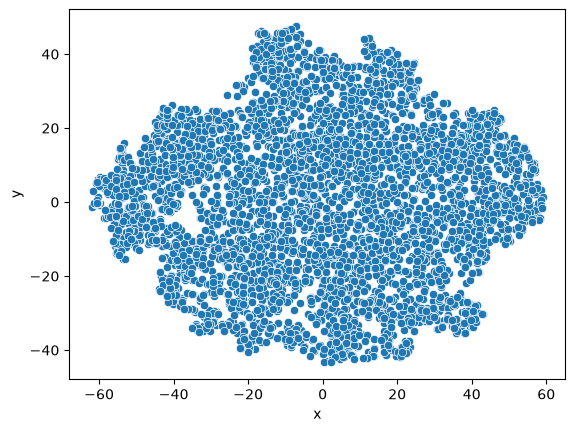

In [5]:
m = TSNE(learning_rate=50)
tsne_features = m.fit_transform(df_num)
tsne_features[1:4,:]

# assign to our dataset so we can plot
df_num['x'] = tsne_features[:,0]
df_num['y'] = tsne_features[:,1]

sns.scatterplot(x='x', y='y' ,data=df_num)
plt.show()

This result being one big cluster makes sense, there are no clear groups of body shapes.

In [9]:
df_num.columns

Index(['abdominalextensiondepthsitting', 'acromialheight',
       'acromionradialelength', 'anklecircumference', 'axillaheight',
       'balloffootcircumference', 'balloffootlength', 'biacromialbreadth',
       'bicepscircumferenceflexed', 'bicristalbreadth', 'bideltoidbreadth',
       'bimalleolarbreadth', 'bitragionchinarc', 'bitragionsubmandibulararc',
       'bizygomaticbreadth', 'buttockcircumference', 'buttockdepth',
       'buttockheight', 'buttockkneelength', 'buttockpopliteallength',
       'calfcircumference', 'cervicaleheight', 'chestbreadth',
       'chestcircumference', 'chestdepth', 'chestheight', 'crotchheight',
       'crotchlengthomphalion', 'crotchlengthposterioromphalion', 'earbreadth',
       'earlength', 'earprotrusion', 'elbowrestheight', 'eyeheightsitting',
       'footbreadthhorizontal', 'footlength', 'forearmcenterofgriplength',
       'forearmcircumferenceflexed', 'forearmforearmbreadth',
       'forearmhandlength', 'functionalleglength', 'handbreadth',
      

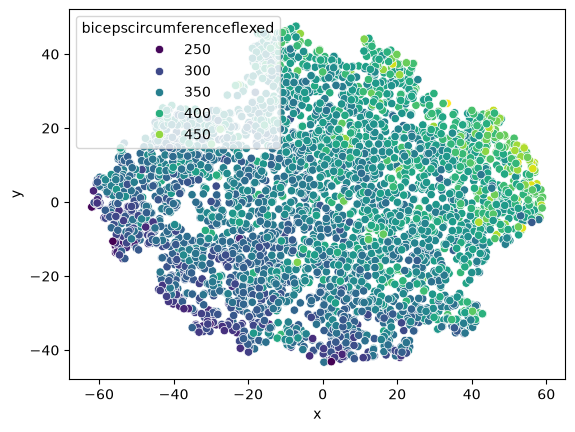

In [16]:
sns.scatterplot(x='x', y='y', hue='bicepscircumferenceflexed', data=df_num, palette='viridis')
plt.show()

### Checking by dropped columns

In [27]:
print(df.select_dtypes(include='str').columns.tolist())

['Branch', 'Component', 'Gender', 'BMI_class', 'Height_class']


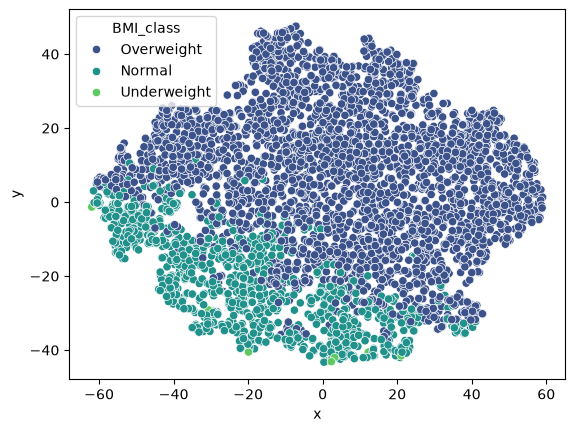

In [29]:
sns.scatterplot(x='x', y='y', hue=df['BMI_class'], data=df_num, palette='viridis')
plt.show()

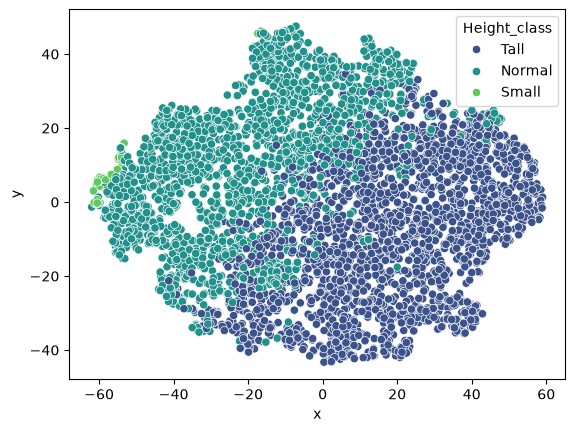

In [30]:
sns.scatterplot(x='x', y='y', hue=df['Height_class'], data=df_num, palette='viridis')
plt.show()

Along the horizontal direction, variance is explained by a person's height class. Tall people sit on the right side of the plot and small people on the left, with normal-height people filling the middle. In conclusion, t-SNE helped us to visually explore our dataset and identify the most important drivers of variance in body shapes.